In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# load CI data
ci_df = pd.read_csv("./data/ci_hourly_202409-202508.csv", parse_dates=["datetime_utc"])
ci_df["hour"] = ci_df["datetime_utc"].dt.hour
ci_df["month"] = ci_df["datetime_utc"].dt.month

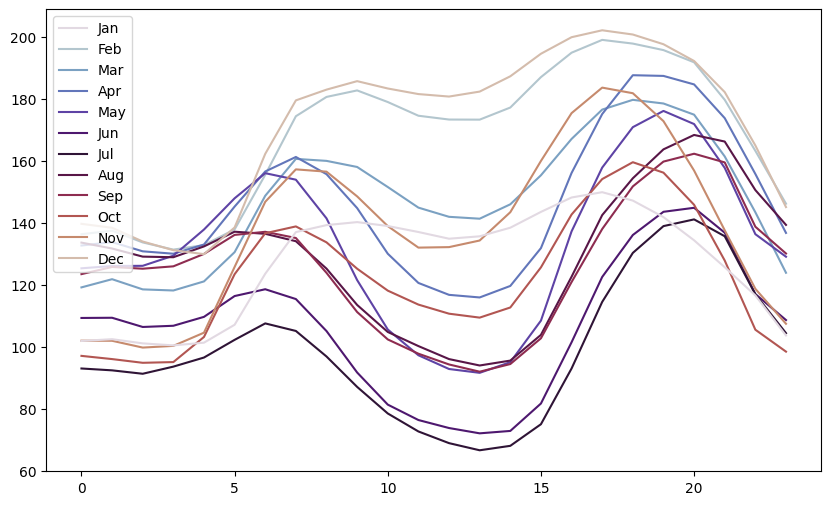

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

for month in range(13):
	color = plt.cm.twilight(month / 12)
	aggregated_ci_df = pd.DataFrame(ci_df[ci_df["month"]==month].groupby("hour").mean()['carbon_intensity_gCO2e_per_kWh'])
	ax.plot(aggregated_ci_df.index, aggregated_ci_df['carbon_intensity_gCO2e_per_kWh'], color=color)

ax.legend(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], loc="upper left")

In [5]:
aggregated_ci_df = pd.DataFrame(ci_df.groupby("hour").describe()['carbon_intensity_gCO2e_per_kWh'])

In [7]:
# get Turing usage data
turing_bask_usage = pd.read_csv("./data/Baskerville_total_commas.csv", index_col=0, parse_dates=["End Time"])
turing_bask_usage["Start Time"] = turing_bask_usage["End Time"] - pd.to_timedelta(turing_bask_usage["Run Time (sec)"], unit='s')
turing_bask_usage["Start Time Hour"] = turing_bask_usage["Start Time"].dt.hour
turing_bask_usage["End Time Hour"] = turing_bask_usage["End Time"].dt.hour

In [8]:
start_date = pd.to_datetime("2024-09-01")
end_date = pd.to_datetime("2025-08-31")

In [9]:
# filter for only relevant date range
turing_bask_usage_filtered = turing_bask_usage[
    (turing_bask_usage["End Time"].dt.date >= start_date.date()
	) & (turing_bask_usage["End Time"].dt.date < end_date.date())
]

In [10]:
# count number of jobs running in each hour
turing_hour_counts = np.zeros(24, dtype=int)

for i, _ in enumerate(turing_bask_usage_filtered.index):
	start_hour = turing_bask_usage_filtered.iloc[i]["Start Time Hour"]
	end_hour = turing_bask_usage_filtered.iloc[i]["End Time Hour"]

	for hour in range(start_hour, end_hour + 1):
		turing_hour_counts[hour] += 1

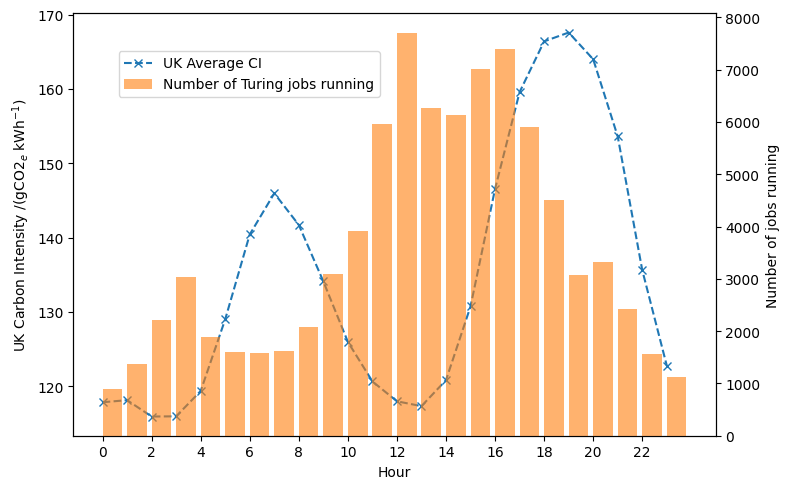

In [12]:
fig, ax0 = plt.subplots(figsize=(8, 5))

ax0.plot(
    aggregated_ci_df.index,
    aggregated_ci_df["mean"],
    marker="x", 
    linestyle="--", 
    color="C0" 
)
ax0.set_ylabel("UK Carbon Intensity /(gCO2${_e}$ kWh$^{-1}$)")

# ax0.fill_between(
#     aggregated_ci_df.index,
#     aggregated_ci_df["mean"] - aggregated_ci_df["std"],
#     aggregated_ci_df["mean"] + aggregated_ci_df["std"],
#     color="C0",
#     alpha=0.2,
# )

ax1 = ax0.twinx()
ax1.bar(
    np.arange(24),
    turing_hour_counts,
    alpha=0.6,
    align="edge",
    color="C1"
)

ax0.set_xlabel("Hour")
ax1.set_ylabel("Number of jobs running")

ax0.set_xticks(np.arange(0, 24, 2))

fig.legend(["UK Average CI", "Number of Turing jobs running"], loc=[0.15, 0.80])
fig.tight_layout()